## Computer Vision

Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and $k$NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5):
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)

In [1]:
# 1

from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


7 

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0  84 185 159 151  60  36   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 222 254 254 254 254 241 198 198 198 198 198 198 19

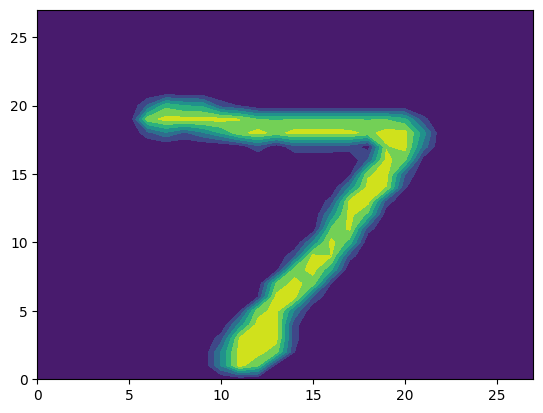

2 

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 116 125 171 255 255 150  93   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0 169 253 253 253 253 253 253 218  30   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 169 253 253 253 213 142 176 253 253 122   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0  52 250 253 210  32  12   0   6 206 253 140   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0  77 251 210  25   0   0   0 122 248 253  65   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  31  18   0   0   0   0 209 253 253  65   

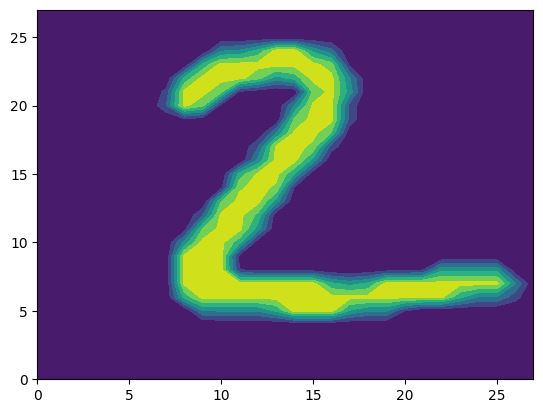

1 

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  38 254 109   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  87 252  82   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 135 241   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  45 244 150   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  84 254  63   

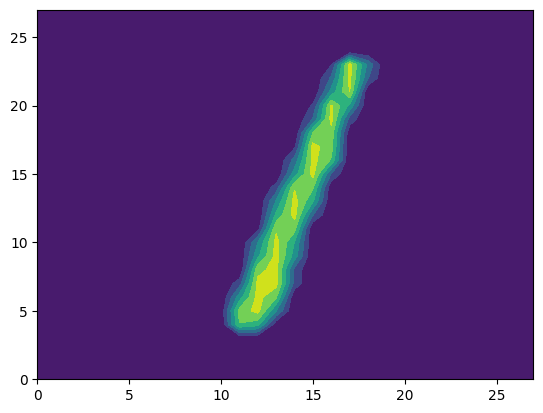

0 

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  11 150 253 202  31   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  37 251 251 253 107   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  21 197 251 251 253 107   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 110 190 251 251 251 253 169 109  62   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 253 251 251 251 251 253 251 251 22

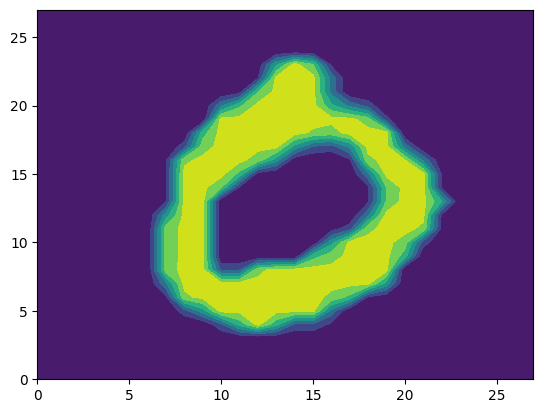

4 

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  50 224   0   0   0   0   0   0   0  70  29   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 121 231   0   0   0   0   0   0   0 148 168   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   4 195 231   0   0   0   0   0   0   0  96 210  11   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  69 252 134   0   0   0   0   0   0   

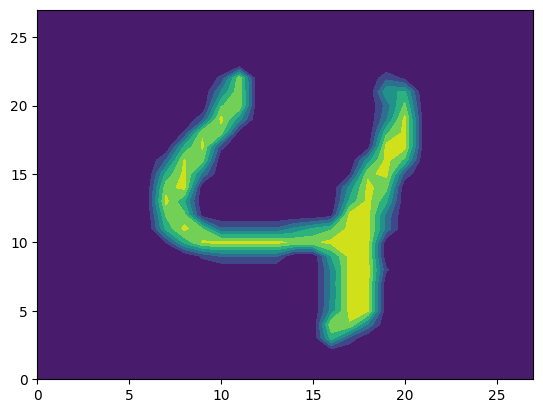

In [2]:
# 1 continued

import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5):
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()

In [3]:
# 2
# What is the shape of X_train and X_test?
shape_X_train = X_train.shape
shape_X_test = X_test.shape
print(f"Shape of X_train: {shape_X_train}")
print(f"Shape of X_test: {shape_X_test}")

# What is the shape of X_train[i] and X_test[i] for each index i?
# Assuming all elements have the same shape, we can check the first element
'''
for i in range(5):
    print(f"Shape of X_train[i] for each i: {X_train[i].shape}")
for i in range(5):
    print(f"Shape of X_test[i] for each i: {X_test[i].shape}")
'''
# Note that if you remove the comments and run that code, i does not change for each i, so simplify to:
print(f"Shape of X_train[i]: {X_train[0].shape}")
print(f"Shape of X_test[i]: {X_test[0].shape}")

# What is the shape of y_train and y_test?
shape_y_train = y_train.shape
shape_y_test = y_test.shape
print(f"Shape of y_train: {shape_y_train}")
print(f"Shape of y_test: {shape_y_test}")

Shape of X_train: (60000, 28, 28)
Shape of X_test: (10000, 28, 28)
Shape of X_train[i]: (28, 28)
Shape of X_test[i]: (28, 28)
Shape of y_train: (60000,)
Shape of y_test: (10000,)


In [6]:
# 3
'''
Use Numpy's .reshape() method to covert the training and testing data from a matrix into an vector of features.
So, X_test[index].reshape((1,784)) will convert the index-th element of X_test into a 28×28=784-length row vector of values, rather than a matrix.
Turn X_train into an N×784 matrix X that is suitable for scikit-learn's kNN classifier where N is the number of observations and 784=28∗28 (you could use, for example, a for loop).
'''
# Reshape X_train
X_train_reshaped = X_train.reshape(X_train.shape[0], 784)

# Reshape X_test
X_test_reshaped = X_test.reshape(X_test.shape[0], 784)

print(f"Shape of X_train_reshaped: {X_train_reshaped.shape}")
print(f"Shape of X_test_reshaped: {X_test_reshaped.shape}")


Shape of X_train_reshaped: (60000, 784)
Shape of X_test_reshaped: (10000, 784)


In [9]:
# 4
# Use the reshaped X_test and y_test data to create a k-nearest neighbor classifier of digit.
# What is the optimal number of neighbors k?
# If you can't determine this, play around with different values of k for your classifier.

# import additional packages
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Establish some trial k values
k_values = range(1, 8) # Decided upon by me as a reasonable range
accuracies = []

# Create KNN Classifier
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_reshaped, y_train)
    y_pred = model.predict(X_test_reshaped)
    accuracies.append(accuracy_score(y_test, y_pred))
    print(f"k={k}, Accuracy: {accuracies[-1]:.4f}")

# Find optimal k
optimal_k_index = np.argmax(accuracies)
optimal_k = list(k_values)[optimal_k_index]
max_accuracy = accuracies[optimal_k_index]
print(f"Optimal k={optimal_k}, Accuracy: {max_accuracy:.4f}")

# Note: This will take a long time to run

k=1, Accuracy: 0.9691
k=2, Accuracy: 0.9627
k=3, Accuracy: 0.9705
k=4, Accuracy: 0.9682
k=5, Accuracy: 0.9688
k=6, Accuracy: 0.9677
k=7, Accuracy: 0.9694
k=8, Accuracy: 0.9670
k=9, Accuracy: 0.9659
k=10, Accuracy: 0.9665
k=11, Accuracy: 0.9668
k=12, Accuracy: 0.9661
k=13, Accuracy: 0.9653
k=14, Accuracy: 0.9640
Optimal k=3, Accuracy: 0.9705


Accuracy: 0.9705


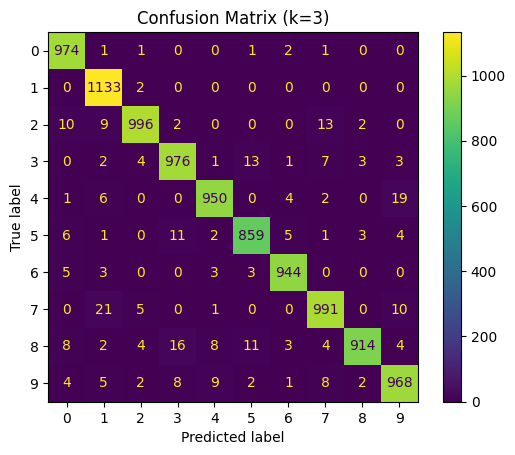

In [10]:
# 5
# For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.

# Import additional packages
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Train final model with optimal k
final_model = KNeighborsClassifier(n_neighbors=optimal_k)
final_model.fit(X_train_reshaped, y_train)
y_pred = final_model.predict(X_test_reshaped)

# Accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot()
plt.title(f"Confusion Matrix (k={optimal_k})")
plt.show()

# Explanation
'''
Generally, the model is extremely accurate at k=3, with an accuracy of 97.05%.
The confusion matrix does not appear to reveal any significant patterns in where the model was making mistakes.
The model was most accurate at predicting a value of 1, with 1133 correct predictions and only 2 incorrect predictions (both predicted as 2).
'''

In [ ]:
# 6
# For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
'''
I could not identify any major patterns in the confusion matrix.
The model generally appeared to decrease in prediction accuracy as the number increases, but that is not 100% correct in all cases,
likely implying that it is not meaningful.
The most accurately predicted value was 1 with 1133 true positives and 2 false positives.
Interestingly, this value also appears at a glance to have one of, if not, the highest false positive quantity.
'''

In [ ]:
# 7
'''
So, this is how computers "see."
They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data.
To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data.
(Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)
'''
# Answer
# Personal note: as someone taking linear algebra concurrently with this course, I find the connection with linear algebra being the language of computers very interesting
'''
Utilizing RBG color hex codes, you could assign every color code from the most white to the most red a value between two set values.
Ypu could then do the same from red to black.  Once you have these established, you should then be able to map any grid of colors as coordinate pairs.
With every color now mapped and coded to a pair, you could use these associated pairs to map a color photo as a matrix of values.
The same reasoning cpuld turn it into tabular data.
'''